# Wavefront error and elements

An ideal coronagraph nulls a perfect wavefront. A real one faces wavefront
error, and that error sets the deep contrast floor. In physicaloptix both
wavefront error and wavefront control enter a path the same way: as a
{class}`~physicaloptix.PhaseScreen` built over a
{class}`~physicaloptix.ModeBasis`, which represents a wavefront as a fixed set
of mode shapes $B_m$ scaled by coefficients $a_m$,

$$\phi(\mathbf{u}) = \frac{2\pi}{\lambda}\sum_m a_m\,B_m(\mathbf{u}).$$

This notebook builds mode bases, turns them into wavefront error, tracks how
that error degrades an image, and shows a coronagraph flooring at speckle
contrast.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

from physicaloptix import (
    Field,
    Fraunhofer,
    Grid,
    MultiScaleVortex,
    OpticalPath,
    PhaseScreen,
    PlaneKind,
    Stage,
    fourier_dm_basis,
    zernike_basis,
)
from physicaloptix.elements import SampledOptic

WL = 500.0
NPUP, NFOC, PSCALE = 96, 200, 0.15
pupil = Grid.pupil(NPUP)
focal = Grid.focal(NFOC, PSCALE)
u = np.asarray(pupil.coords)
ug, vg = np.meshgrid(u, u)
aperture = (np.hypot(ug, vg) <= 0.5).astype(complex)
ap_mask = np.abs(aperture) > 0
flat = Field(data=jnp.asarray(aperture), grid=pupil, plane=PlaneKind.PUPIL)
ext = [-focal.extent, focal.extent] * 2
sci = Stage("sci", Fraunhofer(grid_in=pupil, grid_out=focal))
tele = OpticalPath(stages=(sci,))
peak_flat = float(np.max(np.abs(np.asarray(tele.propagate(flat)[0].data)) ** 2))


def radial_profile(img):
    ny, nx = img.shape
    yy, xx = np.indices((ny, nx))
    r = np.hypot(xx - (nx - 1) / 2, yy - (ny - 1) / 2).astype(int)
    return np.bincount(r.ravel(), img.ravel()) / np.maximum(np.bincount(r.ravel()), 1)

/Users/cspohn/Documents/hwo-dev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Mode bases and their focal signatures

{func}`~physicaloptix.zernike_basis` builds the classical low-order aberrations
(defocus, astigmatism, coma, ...), each already scaled to a nanometer
root-mean-square. Every pupil mode leaves a distinct signature in the focal
plane: defocus spreads a symmetric blur, astigmatism makes a cross, coma throws
a one-sided flare. Each mode below is shown above the PSF it produces on its
own.

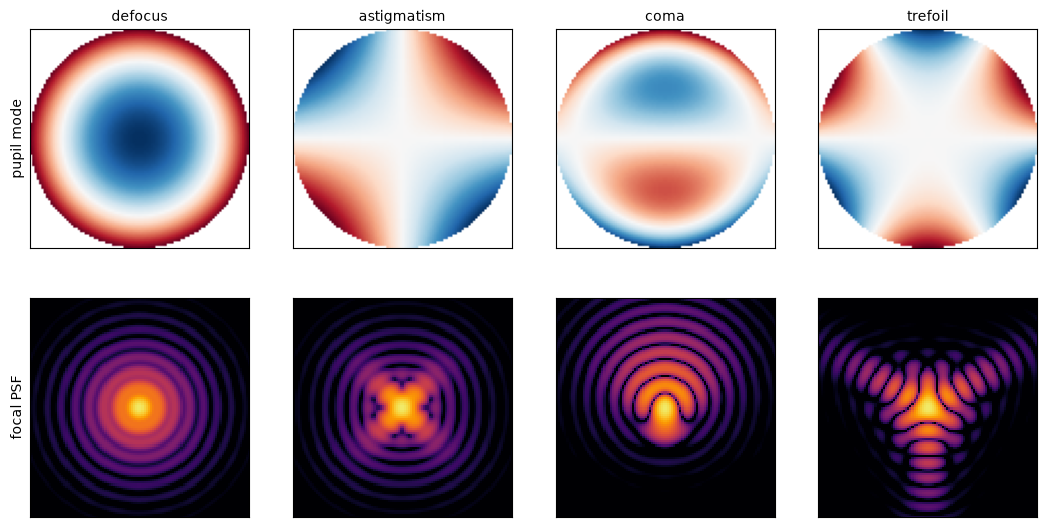

In [2]:
zern = zernike_basis(pupil, 10, rms_nm=1.0)
show = {"defocus": 3, "astigmatism": 4, "coma": 6, "trefoil": 8}

fig, axes = plt.subplots(2, 4, figsize=(13, 6.4))
for col, (name, j) in enumerate(show.items()):
    coeffs = np.zeros(zern.n_modes)
    coeffs[j] = 60.0  # 60 nm rms of this single mode
    basis = eqx.tree_at(lambda b: b.coeffs, zern, jnp.asarray(coeffs))
    screen = PhaseScreen(basis, pupil, wavelength_nm=WL)
    out, _ = OpticalPath(stages=(Stage("wfe", screen), sci)).propagate(flat)
    mode_map = np.where(ap_mask, np.asarray(zern.B[j]), np.nan)
    axes[0, col].imshow(mode_map, origin="lower", cmap="RdBu_r")
    axes[0, col].set_title(name, fontsize=10)
    img = np.abs(np.asarray(out.data)) ** 2 / peak_flat
    axes[1, col].imshow(
        img,
        origin="lower",
        cmap="inferno",
        norm=LogNorm(1e-4, 1),
        extent=ext,
        interpolation="none",
    )
    axes[1, col].set_xlim(-8, 8), axes[1, col].set_ylim(-8, 8)
    for ax in (axes[0, col], axes[1, col]):
        ax.set_xticks([]), ax.set_yticks([])
axes[0, 0].set_ylabel("pupil mode"), axes[1, 0].set_ylabel("focal PSF")
plt.show()

## Building a wavefront from modes

A realistic wavefront is a sum of many modes. Drawing random coefficients gives
an optical-path-difference map, and because each Zernike here carries one
nanometer of root-mean-square per unit coefficient, the coefficient vector is
directly a per-mode error budget. The total wavefront error adds in quadrature,
$\sigma = \sqrt{\sum_m a_m^2}$.

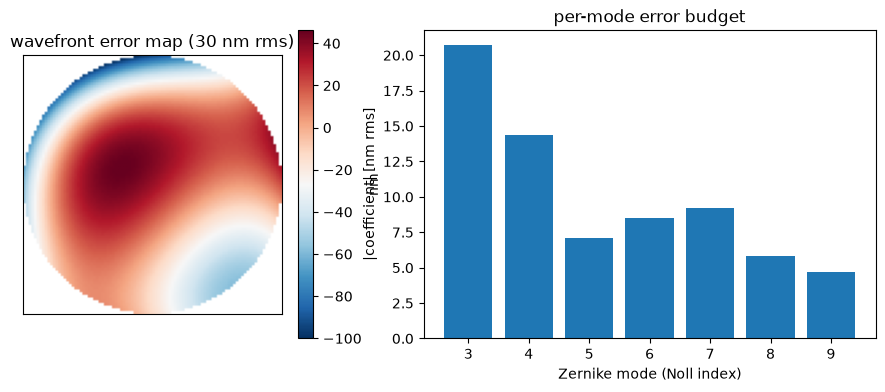

In [3]:
rng = np.random.default_rng(1)
coeffs = rng.standard_normal(zern.n_modes)
coeffs[:3] = 0.0  # drop piston and tilt
coeffs *= 30.0 / np.sqrt(np.sum(coeffs**2))  # scale to 30 nm rms total
opd = np.einsum("m,mij->ij", coeffs, np.asarray(zern.B))

fig, axes = plt.subplots(
    1, 2, figsize=(11, 4.0), gridspec_kw={"width_ratios": [1, 1.4]}
)
im = axes[0].imshow(np.where(ap_mask, opd, np.nan), origin="lower", cmap="RdBu_r")
axes[0].set_title(f"wavefront error map ({np.sqrt(np.sum(coeffs**2)):.0f} nm rms)")
axes[0].set_xticks([]), axes[0].set_yticks([]), fig.colorbar(im, ax=axes[0], label="nm")
axes[1].bar(np.arange(3, zern.n_modes), np.abs(coeffs[3:]), color="C0")
(
    axes[1].set_xlabel("Zernike mode (Noll index)"),
    axes[1].set_ylabel("|coefficient| [nm rms]"),
)
axes[1].set_title("per-mode error budget")
plt.show()

## Wavefront error degrades the image

The Strehl ratio is the peak intensity relative to a perfect wavefront. For
small errors it follows the Marechal approximation

$$S \approx \exp\!\left[-\left(\frac{2\pi\sigma}{\lambda}\right)^2\right],$$

with $\sigma$ the root-mean-square wavefront error. Sweeping a single defocus
mode from zero traces this curve out, and the propagated peaks track it until
the error grows large.

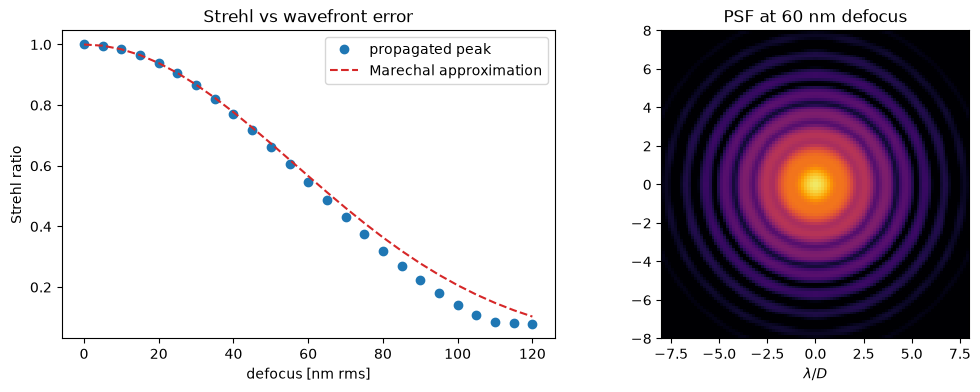

In [4]:
sigmas = np.linspace(0, 120, 25)  # nm rms of defocus
strehls = []
for s in sigmas:
    c = np.zeros(zern.n_modes)
    c[3] = s
    scr = PhaseScreen(
        eqx.tree_at(lambda b: b.coeffs, zern, jnp.asarray(c)), pupil, wavelength_nm=WL
    )
    out, _ = OpticalPath(stages=(Stage("wfe", scr), sci)).propagate(flat)
    strehls.append(float(np.max(np.abs(np.asarray(out.data)) ** 2)) / peak_flat)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.0), gridspec_kw={"width_ratios": [1.4, 1]}
)
axes[0].plot(sigmas, strehls, "o", color="C0", label="propagated peak")
axes[0].plot(
    sigmas,
    np.exp(-((2 * np.pi * sigmas / WL) ** 2)),
    "--",
    color="C3",
    label="Marechal approximation",
)
axes[0].set_xlabel("defocus [nm rms]"), axes[0].set_ylabel("Strehl ratio")
axes[0].set_title("Strehl vs wavefront error"), axes[0].legend()

thumbs = np.zeros((NFOC, NFOC))
for s in (0.0, 60.0, 120.0):
    c = np.zeros(zern.n_modes)
    c[3] = s
    scr = PhaseScreen(
        eqx.tree_at(lambda b: b.coeffs, zern, jnp.asarray(c)), pupil, wavelength_nm=WL
    )
    out, _ = OpticalPath(stages=(Stage("wfe", scr), sci)).propagate(flat)
    if s == 60.0:
        mid = np.abs(np.asarray(out.data)) ** 2 / peak_flat
im = axes[1].imshow(
    mid,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-4, 1),
    extent=ext,
    interpolation="none",
)
axes[1].set_xlim(-8, 8), axes[1].set_ylim(-8, 8)
axes[1].set_title("PSF at 60 nm defocus"), axes[1].set_xlabel(r"$\lambda/D$")
plt.show()

## From wavefront error to speckles

A single sinusoidal wavefront ripple of $k$ cycles across the aperture does
something specific: it scatters a **pair of speckles** to $\pm k\,\lambda/D$ in
the focal plane. The halo a coronagraph must fight is the sum of these pairs
over every spatial frequency in the wavefront error. This is the entry point to
[speckles from first principles](05_Speckles_from_First_Principles).

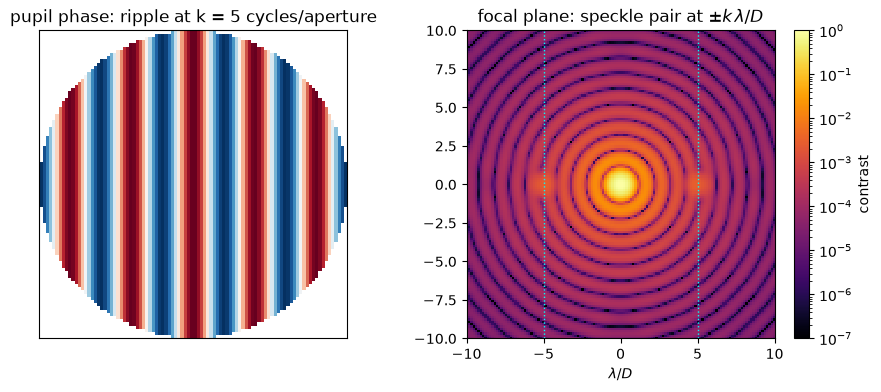

In [5]:
k = 5.0
ripple = aperture * np.exp(1j * 2 * np.pi * (8.0 * np.cos(2 * np.pi * k * ug)) / WL)
out, _ = tele.propagate(
    Field(data=jnp.asarray(ripple), grid=pupil, plane=PlaneKind.PUPIL)
)
img = np.abs(np.asarray(out.data)) ** 2 / peak_flat

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].imshow(
    np.where(ap_mask, np.angle(ripple), np.nan), origin="lower", cmap="RdBu_r"
)
axes[0].set_title(f"pupil phase: ripple at k = {k:.0f} cycles/aperture")
axes[0].set_xticks([]), axes[0].set_yticks([])
im = axes[1].imshow(
    img,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-7, 1),
    extent=ext,
    interpolation="none",
)
for s in (-k, k):
    axes[1].axvline(s, color="cyan", ls=":", lw=1)
axes[1].set_xlim(-10, 10), axes[1].set_ylim(-10, 10)
axes[1].set_title(r"focal plane: speckle pair at $\pm k\,\lambda/D$")
axes[1].set_xlabel(r"$\lambda/D$"), fig.colorbar(im, ax=axes[1], label="contrast")
plt.show()

## The coronagraph floor

Feed a few nanometers of multi-mode error to the vortex coronagraph and its
deep null rises to the speckle level: a focal-plane mask removes the *core* of
the star, not the halo the wavefront error scatters around it. The
azimuthally-averaged contrast curve makes the floor quantitative, decades above
the perfect-wavefront case.

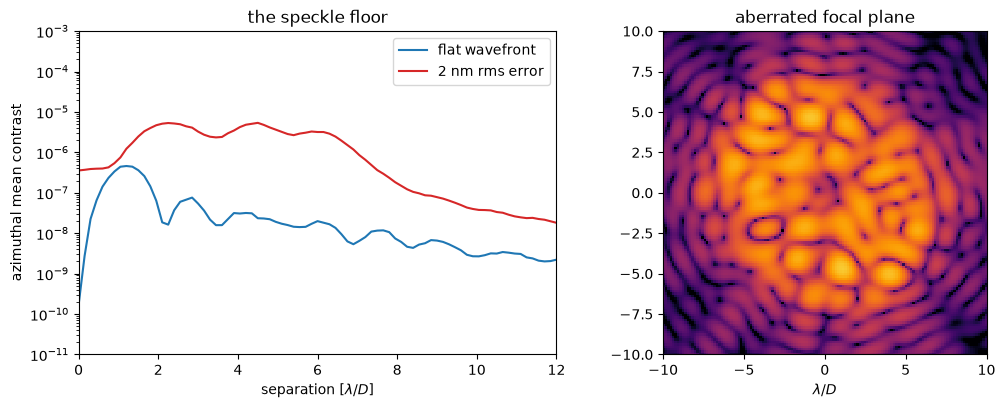

In [6]:
vortex = MultiScaleVortex.build(
    charge=2, npup=NPUP, q=64, scaling_factor=4, window_size=16
)
lyot = SampledOptic(
    transmission=jnp.asarray(((ug**2 + vg**2) <= 0.45**2).astype(float)),
    grid=pupil,
    plane=PlaneKind.PUPIL,
)

fourier = fourier_dm_basis(pupil, n_actuators=14, k_min=2.0, k_max=8.0)
err = rng.standard_normal(fourier.n_modes)
err *= 2.0 / np.sqrt(np.sum(err**2))  # 2 nm rms total
err_screen = PhaseScreen(
    eqx.tree_at(lambda b: b.coeffs, fourier, jnp.asarray(err)), pupil, wavelength_nm=WL
)


def coro(pre):
    return OpticalPath(stages=(*pre, Stage("vortex", vortex), Stage("lyot", lyot), sci))


perfect = np.abs(np.asarray(coro(()).propagate(flat)[0].data)) ** 2 / peak_flat
aberr = (
    np.abs(np.asarray(coro((Stage("wfe", err_screen),)).propagate(flat)[0].data)) ** 2
    / peak_flat
)
rr = np.arange(len(radial_profile(perfect))) * PSCALE

fig, axes = plt.subplots(
    1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.3, 1]}
)
axes[0].semilogy(rr, radial_profile(perfect), color="C0", label="flat wavefront")
axes[0].semilogy(rr, radial_profile(aberr), color="C3", label="2 nm rms error")
axes[0].set_xlim(0, 12), axes[0].set_ylim(1e-11, 1e-3)
(
    axes[0].set_xlabel(r"separation [$\lambda/D$]"),
    axes[0].set_ylabel("azimuthal mean contrast"),
)
axes[0].set_title("the speckle floor"), axes[0].legend()
im = axes[1].imshow(
    aberr,
    origin="lower",
    cmap="inferno",
    norm=LogNorm(1e-9, 1e-4),
    extent=ext,
    interpolation="none",
)
axes[1].set_xlim(-10, 10), axes[1].set_ylim(-10, 10)
axes[1].set_title("aberrated focal plane"), axes[1].set_xlabel(r"$\lambda/D$")
plt.show()

## The control basis sets the dark hole

A deformable mirror can only write the spatial frequencies its actuators
resolve. A band-limited {func}`~physicaloptix.fourier_dm_basis` spanning
$k_\text{min}$ to $k_\text{max}$ cycles per aperture can therefore only correct
speckles between $k_\text{min}$ and $k_\text{max}\;\lambda/D$, which is the
annular **dark hole** it can dig. Choosing that band is a control design
decision; the correction loop that drives it lives in the `tiptilt` library,
consuming these same `PhaseScreen` and `ModeBasis` elements.

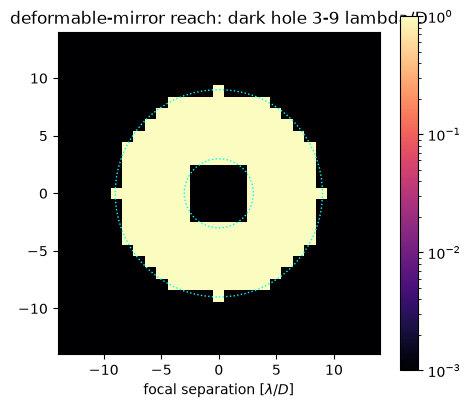

In [7]:
k_min, k_max = 3.0, 9.0
dm = fourier_dm_basis(pupil, n_actuators=20, k_min=k_min, k_max=k_max)
reach = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(dm.B).sum(axis=0)))) ** 2
reach /= reach.max()
kx = np.fft.fftshift(np.fft.fftfreq(NPUP, d=1.0 / NPUP))

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(
    reach,
    origin="lower",
    cmap="magma",
    norm=LogNorm(1e-3, 1),
    extent=[kx[0], kx[-1]] * 2,
    interpolation="none",
)
for kc in (k_min, k_max):
    ax.add_patch(plt.Circle((0, 0), kc, fill=False, color="cyan", ls=":", lw=1))
ax.set_xlim(-14, 14), ax.set_ylim(-14, 14)
ax.set_title(f"deformable-mirror reach: dark hole {k_min:.0f}-{k_max:.0f} lambda/D")
ax.set_xlabel(r"focal separation [$\lambda/D$]"), fig.colorbar(im, ax=ax)
plt.show()

## Where to go next

- **[Speckles from first principles](05_Speckles_from_First_Principles)** builds
  the theory of how wavefront error becomes a speckle halo, why picometers are
  the contrast currency, and how two wavefront quadratures set what a deformable
  mirror can and cannot correct.
- **Closing the loop.** Digging a dark hole with real wavefront sensing and
  control lives in the `tiptilt` library, which drives these same
  `PhaseScreen` and `ModeBasis` elements.
- Other bases exist for other jobs: `segment_ptt_basis` gives per-segment
  piston, tip, and tilt for a segmented primary, and a `ModeBasis` can hold any
  set of shapes you supply.